<a href="https://colab.research.google.com/github/23tq1a0580/GREENWATT/blob/main/GREENWATT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib


In [3]:
data = pd.read_csv("/content/train.csv")

print(data.head())

             timestamp  active_power_calculated_by_converter  \
0  2021-02-19 20:18:00                            816.636759   
1  2021-04-27 04:55:00                            419.107829   
2  2021-01-25 06:26:00                           1303.530558   
3  2021-10-30 03:47:00                             61.494872   
4  2021-03-15 00:39:00                            593.514364   

   active_power_raw  ambient_temperature  generator_speed  \
0        834.917206            31.694380      1159.616602   
1        421.050873            12.894948       928.747996   
2       1337.566142            16.648388      1201.219775   
3         53.481008            28.388141       769.806122   
4        611.659108            31.519527      1046.916768   

   generator_winding_temp_max  grid_power10min_average  nc1_inside_temp  \
0                   65.954214               917.897085        31.881972   
1                   59.571319               445.554250        32.423705   
2                   61.

In [4]:
print(data.shape)
print(data.columns)
print(data.info())

(722, 16)
Index(['timestamp', 'active_power_calculated_by_converter', 'active_power_raw',
       'ambient_temperature', 'generator_speed', 'generator_winding_temp_max',
       'grid_power10min_average', 'nc1_inside_temp', 'nacelle_temp',
       'reactice_power_calculated_by_converter', 'reactive_power',
       'wind_direction_raw', 'wind_speed_raw', 'wind_speed_turbulence',
       'turbine_id', 'Target'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   timestamp                               722 non-null    object 
 1   active_power_calculated_by_converter    722 non-null    float64
 2   active_power_raw                        722 non-null    float64
 3   ambient_temperature                     722 non-null    float64
 4   generator_speed                         722 n

In [5]:
print(data.isnull().sum())

timestamp                                 0
active_power_calculated_by_converter      0
active_power_raw                          0
ambient_temperature                       0
generator_speed                           0
generator_winding_temp_max                0
grid_power10min_average                   0
nc1_inside_temp                           0
nacelle_temp                              0
reactice_power_calculated_by_converter    0
reactive_power                            0
wind_direction_raw                        0
wind_speed_raw                            0
wind_speed_turbulence                     0
turbine_id                                0
Target                                    0
dtype: int64


In [6]:
data = data.dropna()

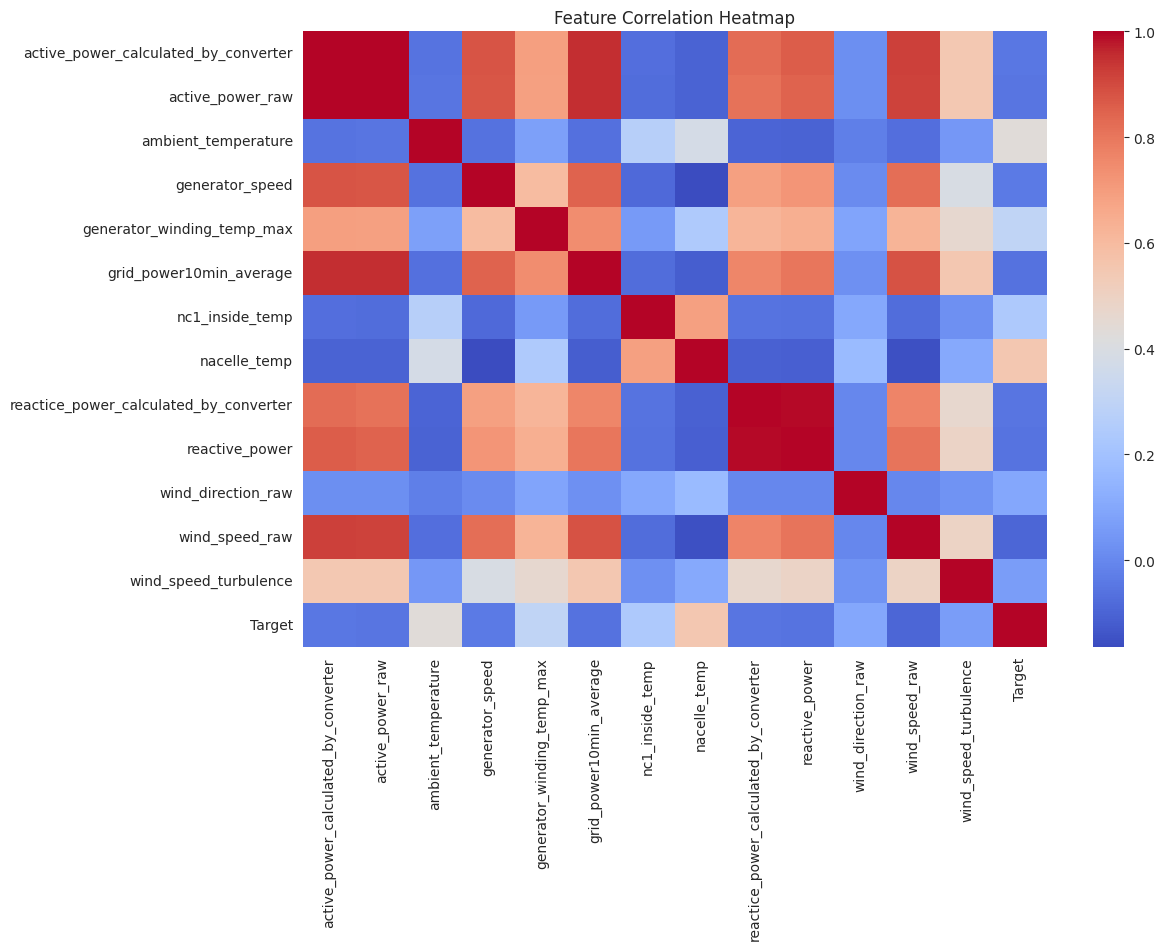

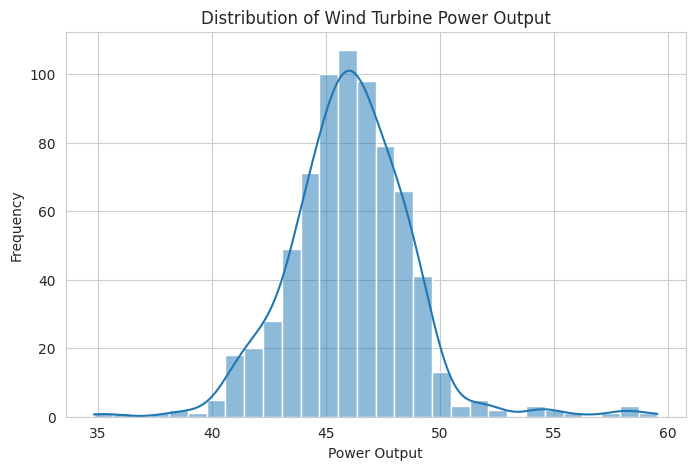

In [7]:
# -----------------------------
# DATA ANALYSIS AND VISUALIZATION
# -----------------------------

# Set style
sns.set_style("whitegrid")

# 1️⃣ Correlation Heatmap
plt.figure(figsize=(12,8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# 2️⃣ Target Distribution
plt.figure(figsize=(8,5))
sns.histplot(data["Target"], bins=30, kde=True)
plt.title("Distribution of Wind Turbine Power Output")
plt.xlabel("Power Output")
plt.ylabel("Frequency")
plt.show()


# 3️⃣ Wind Speed vs Power Output
if "wind_speed" in data.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=data["wind_speed"], y=data["Target"])
    plt.title("Wind Speed vs Power Output")
    plt.xlabel("Wind Speed")
    plt.ylabel("Power Output")
    plt.show()


# 4️⃣ Temperature vs Power Output
if "temperature" in data.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=data["temperature"], y=data["Target"])
    plt.title("Temperature vs Power Output")
    plt.xlabel("Temperature")
    plt.ylabel("Power Output")
    plt.show()


# 5️⃣ Feature Importance (after training Random Forest)

In [8]:
X = data.drop("Target", axis=1)
y = data["Target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np # Import numpy for np.number

# Identify numerical and categorical features
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').drop(columns=['timestamp'], errors='ignore').columns.tolist()

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop' # Drop any other columns not specified (like 'timestamp')
)

lr_model = Pipeline([
    ("prep", preprocessor),
    ("lr", LinearRegression())
])
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("\nLinear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²:", r2_score(y_test, y_pred_lr))


Linear Regression Results:
MAE: 1.2024614836280392
RMSE: 1.8541407170642472
R²: 0.4848712261591702


In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Drop non-numeric columns 'timestamp' and 'turbine_id' from X_train and X_test
# before fitting the model.
columns_to_drop = ['timestamp', 'turbine_id']
X_train_processed = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test_processed = X_test.drop(columns=columns_to_drop, errors='ignore')

model.fit(X_train_processed, y_train)

RandomForestRegressor(random_state=42)

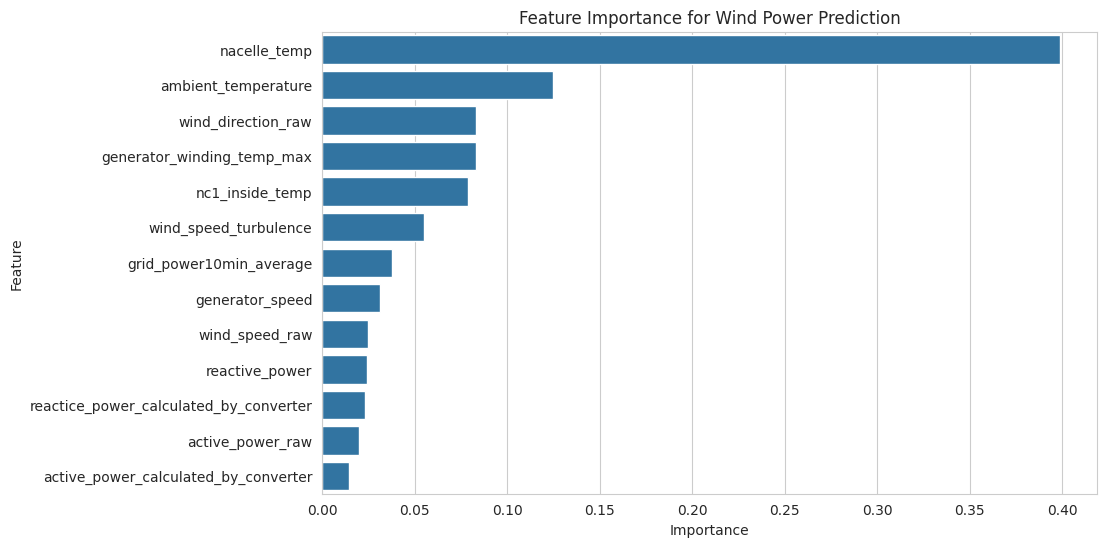

In [12]:
# -----------------------------
# Feature Importance Graph
# -----------------------------
importances = model.feature_importances_

features = X_train_processed.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance for Wind Power Prediction")
plt.show()

In [13]:
y_pred = model.predict(X_test_processed)

In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 4.083812531388759
R2 Score: 0.3880777788002143


In [15]:
joblib.dump(model, "model.pkl")

print("Model saved successfully")

Model saved successfully
